In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
offer_events = pd.read_csv(r'C:\Users\gerem\Desktop\datathon-7mlet-grupo-77\data\synthetic_enrichment\offer_events.csv', sep=',')

offer_events.head()

,event_id,subject_key,occurred_at,channel,arm_id,arm_name,reward,idade,profissao,estado_civil,...,numero_contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_preco_consumidor,indice_confianca_consumidor,taxa_euribor_3_meses,numero_empregados,conversao,cliente_ja_contatado,faixa_contatos
0,evt_000001,subject_000001,2025-01-01 00:00:00,whatsapp,0,sem_oferta,0,56,housemaid,married,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
1,evt_000002,subject_000002,2025-01-01 00:01:00,email,3,cartao_premium,0,57,services,married,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
2,evt_000003,subject_000003,2025-01-01 00:02:00,whatsapp,2,simulador_credito,0,37,services,married,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
3,evt_000004,subject_000004,2025-01-01 00:03:00,web,1,educacao_financeira,0,40,admin.,married,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
4,evt_000005,subject_000005,2025-01-01 00:04:00,email,1,educacao_financeira,0,56,services,married,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1


In [3]:
reward_medio_geral = offer_events["reward"].mean()

print(f"Reward médio geral: {reward_medio_geral:.2%}")

Reward médio geral: 11.27%


In [4]:
reward_por_arm = (
    offer_events
    .groupby("arm_name")["reward"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={
        "count": "quantidade_eventos",
        "mean": "reward_medio"
    })
    .sort_values("reward_medio", ascending=False)
)

reward_por_arm

,arm_name,quantidade_eventos,reward_medio
0,cartao_premium,10249,0.118646
1,educacao_financeira,10174,0.111166
2,sem_oferta,10387,0.111004
3,simulador_credito,10378,0.109848


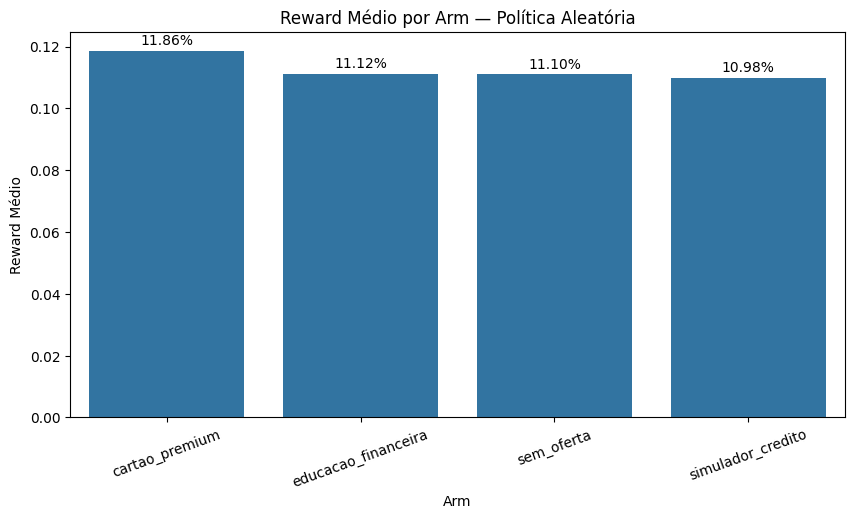

In [5]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=reward_por_arm,
    x="arm_name",
    y="reward_medio"
)

for i, row in reward_por_arm.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["reward_medio"] + 0.002,
        f"{row['reward_medio']:.2%}",
        ha="center",
        fontsize=10
    )

plt.title("Reward Médio por Arm — Política Aleatória")
plt.xlabel("Arm")
plt.ylabel("Reward Médio")
plt.xticks(rotation=20)
plt.show()

In [6]:
baseline_result = {
    "policy_name": "random_policy",
    "description": "Política baseline com escolha aleatória de arms.",
    "reward_mean": reward_medio_geral,
    "total_events": len(offer_events),
}

baseline_result

{'policy_name': 'random_policy',
 'description': 'Política baseline com escolha aleatória de arms.',
 'reward_mean': np.float64(0.11265417111780131),
 'total_events': 41188}

## Conclusão

A política baseline utilizada nesta etapa é uma política aleatória, na qual os braços de decisão foram distribuídos de forma randômica entre os eventos sintéticos.

Essa abordagem representa um cenário inicial sem aprendizado adaptativo, servindo como referência para comparação com algoritmos de Multi-Armed Bandits.

O reward médio obtido pela política aleatória será utilizado como métrica-base para avaliar se a política adaptativa consegue melhorar a tomada de decisão.